In [57]:
from pathlib import Path
from IPython.lib.display import Audio

%load_ext autoreload
%autoreload 2

from src.main.controller.AASVCController import AASVCController
from src.common.utils.visualizar import vizualizar_spectrogram

ROOT = Path.cwd().resolve().parent.parent.parent
print(ROOT)
path_dataset = ROOT / "dataset" / "cv-corpus-mozilla-pt" / "data"
path_model_checkpoint = ROOT / "src"/ "config" / "modelCheckpoint" / "AASVC" / "checkpoint-20000steps.pkl"
path_model_params = ROOT / "src"/ "config" / "modelCheckpoint" / "AASVC" / "aas_vc.melmelmel.v1.yaml"

print(path_dataset)
print(path_model_checkpoint)

controller = AASVCController(batch_size=2,path_dataset=path_dataset)
# path_dataset = r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\dataset\cv-corpus-mozilla-pt\data/"
#path_model_checkpoint = r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\src\config\modelCheckpoint\AASVC\checkpoint-250000steps.pkl"
mel_inference, mel_original , mel_noise =controller.all_mels(path_model_checkpoint,path_model_params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC
C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\dataset\cv-corpus-mozilla-pt\data
C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\src\config\modelCheckpoint\AASVC\checkpoint-20000steps.pkl


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\USER\_netrc


HiFi-GAN: Removing weight norm.
torch.Size([354, 80])
torch.Size([354, 80])
torch.Size([1, 354, 80])


In [55]:
print(mel_original.shape)
print(mel_noise.shape)
print(mel_inference.shape)

torch.Size([80, 354])
torch.Size([80, 354])
torch.Size([1, 80, 344])


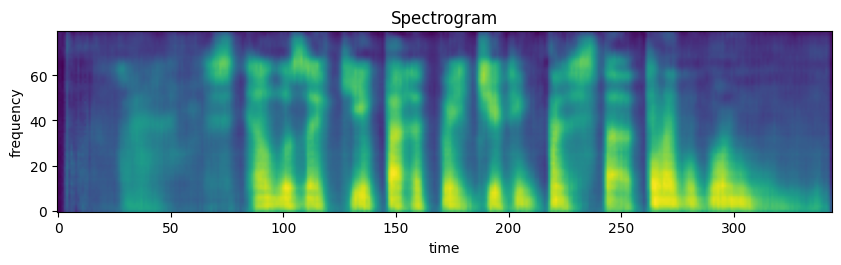

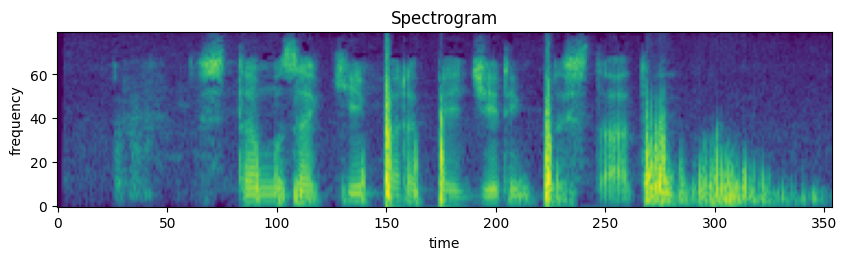

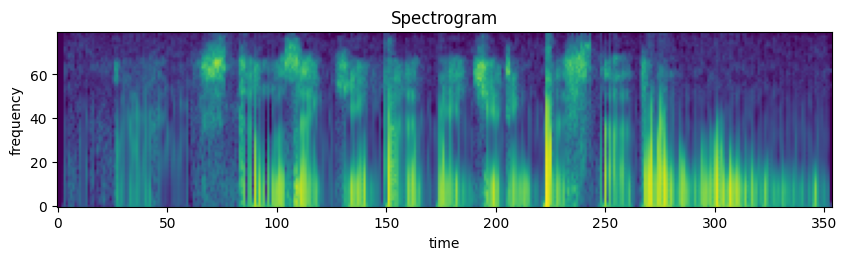

In [53]:
%matplotlib inline

vizualizar_spectrogram(mel_inference[0])
vizualizar_spectrogram(mel_original)
vizualizar_spectrogram(mel_noise)

In [74]:
from src.common.utils.visualizar import salvar_comparacao_mel

salvar_comparacao_mel(
    mel_entrada=mel_noise,
    mel_ground_truth= mel_original,
    mel_modelo=mel_inference.cpu().detach().numpy(),
    save_path=r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\inference\AASVC\resultado_artigo.png"
)

Imagem salva em: C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\inference\AASVC\resultado_artigo.png


In [ ]:
audio,mel_m,mel_noise, mel_org, audio_org = controller.inference(path_model_checkpoint, path_dataset)

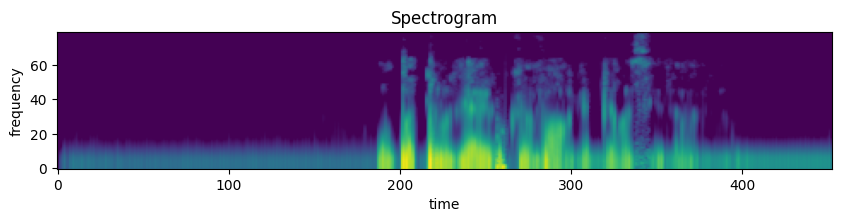

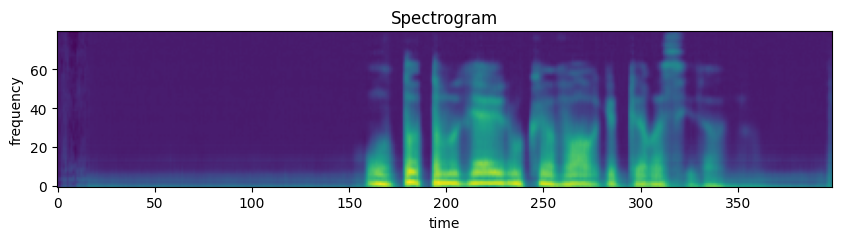

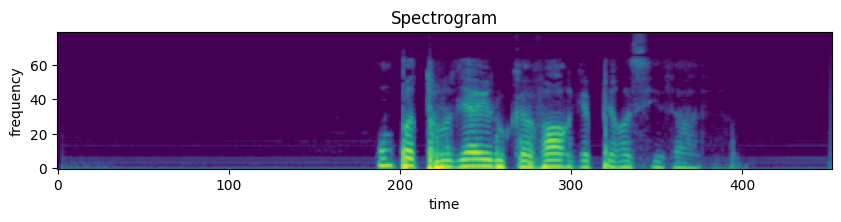

In [3]:
import torch

vizualizar_spectrogram(torch.Tensor(mel_noise).transpose(0,1))
vizualizar_spectrogram(mel_m.transpose(0,1))
vizualizar_spectrogram(torch.Tensor(mel_org).transpose(0,1))


HiFi-GAN: Removing weight norm.


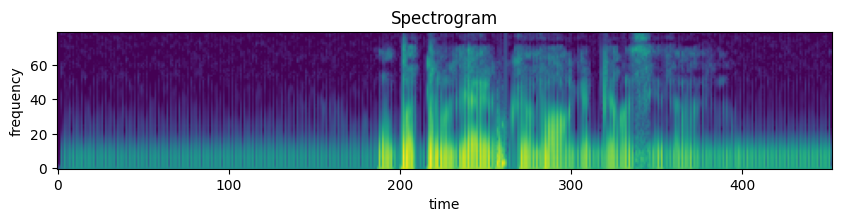

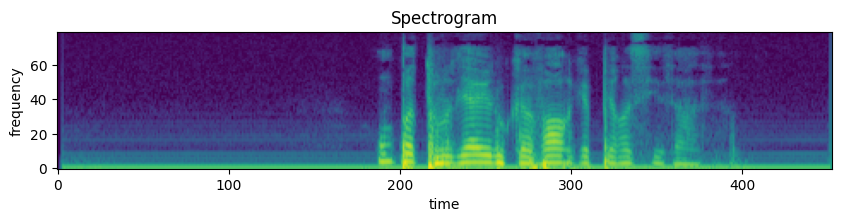

In [6]:
from src.common.pre_processamento.noise import f0_constante
from src.common.pre_processamento.spectograma import gerar_mel_spectogram
import numpy as np
import librosa
from src.common.vocoder.HiFiGAN import inference

def create_mel(audio):
    return gerar_mel_spectogram(audio)
    # mel = librosa.feature.melspectrogram(
    #         y=audio_org,
    #         sr=22050,
    #         n_fft=1024,
    #         hop_length=256,
    #         win_length=None,
    #         n_mels=80,
    #         fmin=80,
    #         fmax=22050 // 2, # 7600
    #         power=2.0,
    #     )
    # # converte para log-mel
    # mel = librosa.power_to_db(mel, ref=np.max)
    # 
    # # mel vem (80, T) → queremos (T, 80)
    # mel = mel.T

audio_ruido = f0_constante(audio_org.astype(np.float64), 22050, f0_floor=25.0, f0_ceil=90.0, frame_period=1.0, speed=1, f0_contante=60.0)
mel = create_mel(torch.Tensor(audio_ruido))
mel_n = create_mel(torch.Tensor(audio_org))
vizualizar_spectrogram(torch.Tensor(mel))
vizualizar_spectrogram(torch.Tensor(mel_n))

mel_for_vocoder = torch.Tensor(mel)
audio_pred = inference(torch.Tensor(mel_for_vocoder).to('cuda')).cpu().detach()
audio_pred = audio_pred[0].cpu().detach().numpy()
Audio(audio_ruido, rate=22050)

In [ ]:
Audio(audio_pred, rate=22050)

In [221]:
Audio(audio, rate=22050)